In [1]:
print("hi")

hi


## **load** libaries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# loading data

In [3]:
data=pd.read_csv("/content/cancer_data.csv")
print(data)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

### Dimenionsality **reduction**

In [4]:
data_final=data.iloc[:,1:4]
print(data_final)

    diagnosis  radius_mean  texture_mean
0           M        17.99         10.38
1           M        20.57         17.77
2           M        19.69         21.25
3           M        11.42         20.38
4           M        20.29         14.34
..        ...          ...           ...
564         M        21.56         22.39
565         M        20.13         28.25
566         M        16.60         28.08
567         M        20.60         29.33
568         B         7.76         24.54

[569 rows x 3 columns]


<Axes: >

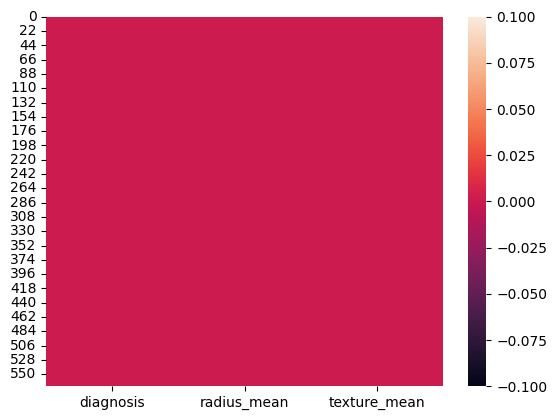

In [5]:
sns.heatmap(data_final.isnull())

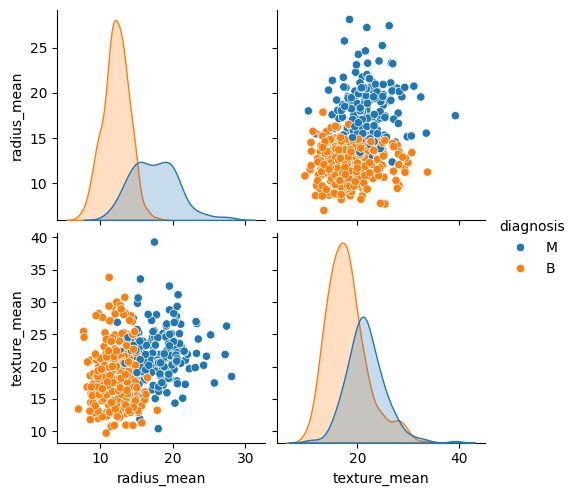

In [6]:
sns.pairplot(data_final,hue='diagnosis')

In [7]:
x=data_final.iloc[:,1:].values
y=data_final.iloc[:,0].values
print(x)
print(y)

[[17.99 10.38]
 [20.57 17.77]
 [19.69 21.25]
 ...
 [16.6  28.08]
 [20.6  29.33]
 [ 7.76 24.54]]
['M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'B' 'B' 'B' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'B' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'M'
 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'M' 'B'
 'M' 'M' 'B' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B'
 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B'
 'M' 'M' 'B' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'M' 'B' 'B' 'M' 'B' 'B'
 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'M'
 'M' 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'M' 'B' 'B'
 'M' 'M' 'M' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'M' 'M'
 'M' 'M' 'B' 'M' 'M' 'M' 'B' 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'M' 'M' 'M' 'M'
 'B' 'B' 'M' 'M' 'B' 'B' 'B'

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.2,random_state=0)

### KNN

### **TRAINING**

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

### **Analysis**

In [10]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [11]:
knn_preds= knn.predict(x_test)

In [12]:
print(confusion_matrix(y_test,knn_preds))

[[60  7]
 [11 36]]


<Axes: >

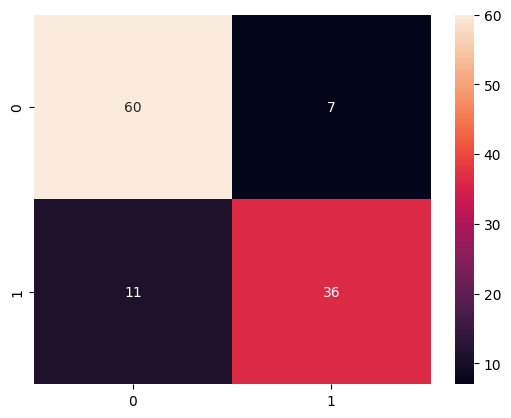

In [13]:
sns.heatmap(confusion_matrix(y_test,knn_preds),annot=True)

In [14]:
crknn=classification_report(y_test,knn_preds)
print(crknn)

              precision    recall  f1-score   support

           B       0.85      0.90      0.87        67
           M       0.84      0.77      0.80        47

    accuracy                           0.84       114
   macro avg       0.84      0.83      0.83       114
weighted avg       0.84      0.84      0.84       114



In [15]:
knnac=accuracy_score(y_test,knn_preds)
print(knnac)

0.8421052631578947


## **Logistic regression**

In [16]:
from sklearn.linear_model import LogisticRegression
logm=LogisticRegression()
logm.fit(x_train,y_train)


LogisticRegression()

In [17]:
logm_pred=logm.predict(x_test)

In [18]:
print(confusion_matrix(y_test,logm_pred))

[[62  5]
 [ 7 40]]


<Axes: >

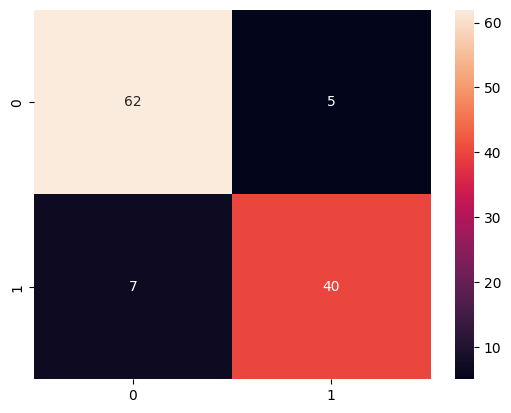

In [19]:
sns.heatmap(confusion_matrix(y_test,logm_pred),annot=True)

In [20]:
crlogm=classification_report(y_test,logm_pred)
print(crlogm)

              precision    recall  f1-score   support

           B       0.90      0.93      0.91        67
           M       0.89      0.85      0.87        47

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114



In [21]:
aclogm=accuracy_score(y_test,logm_pred)
print(aclogm)

0.8947368421052632


# **Naive bayes Classifier**


In [22]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [23]:
nb_pred=nb.predict(x_test)

<Axes: >

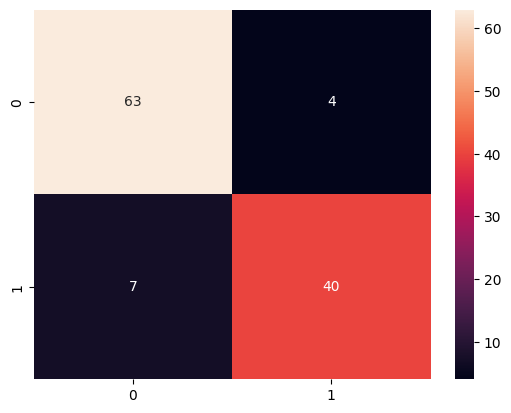

In [24]:
sns.heatmap(confusion_matrix(y_test,nb_pred),annot=True)

In [25]:
crnb=classification_report(y_test,nb_pred)
print(crnb)

              precision    recall  f1-score   support

           B       0.90      0.94      0.92        67
           M       0.91      0.85      0.88        47

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114



In [26]:
acnb=accuracy_score(y_test,nb_pred)
print(acnb)

0.9035087719298246


### **SVM **

In [27]:
from sklearn.svm import SVC
svm_model=SVC(kernel="linear")
svm_model.fit(x_train,y_train)

SVC(kernel='linear')

In [28]:
svm_pred=svm_model.predict(x_test)

<Axes: >

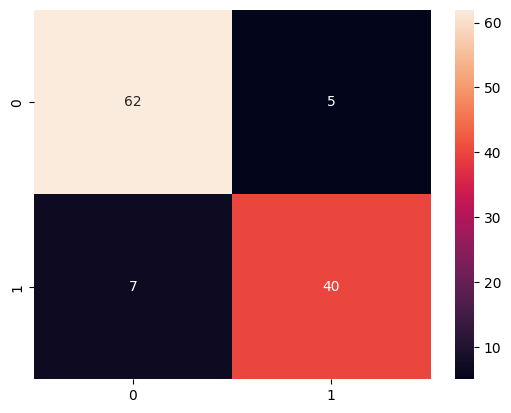

In [29]:
sns.heatmap(confusion_matrix(y_test,svm_pred),annot=True)

In [30]:
svmcr=classification_report(y_test,svm_pred)
print(svmcr)

              precision    recall  f1-score   support

           B       0.90      0.93      0.91        67
           M       0.89      0.85      0.87        47

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114



In [31]:
acsvm=accuracy_score(y_test,svm_pred)
print(acsvm)

0.8947368421052632


# **decision tree**

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [33]:
dt_pred=dt.predict(x_test)

<Axes: >

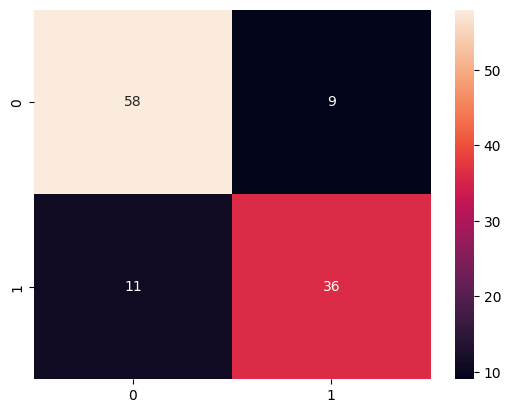

In [34]:
cmdt=confusion_matrix(y_test,dt_pred)
sns.heatmap(cmdt,annot=True)

In [35]:
crdt=classification_report(y_test,dt_pred)
print(crdt)

              precision    recall  f1-score   support

           B       0.84      0.87      0.85        67
           M       0.80      0.77      0.78        47

    accuracy                           0.82       114
   macro avg       0.82      0.82      0.82       114
weighted avg       0.82      0.82      0.82       114



In [36]:
acdt=accuracy_score(y_test,dt_pred)
print(acdt)

0.8245614035087719


### **random forest**

In [37]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=10)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=10)

In [38]:
rf_pred=rf.predict(x_test)

<Axes: >

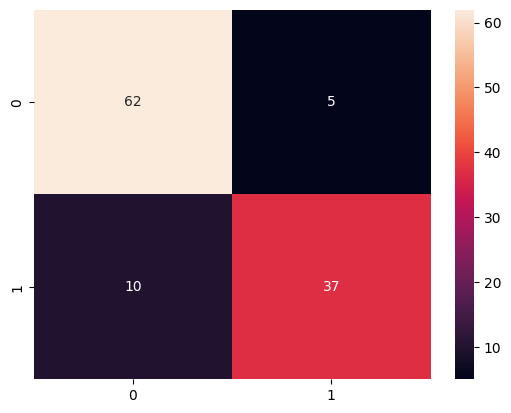

In [39]:
cmrf=confusion_matrix(y_test,rf_pred)
sns.heatmap(cmrf,annot=True)

In [40]:
crrf=classification_report(y_test,rf_pred)
print(crrf)

              precision    recall  f1-score   support

           B       0.86      0.93      0.89        67
           M       0.88      0.79      0.83        47

    accuracy                           0.87       114
   macro avg       0.87      0.86      0.86       114
weighted avg       0.87      0.87      0.87       114



In [41]:
aurf=accuracy_score(y_test,rf_pred)
print(aurf)

0.868421052631579
